#**Importing dataset and analysing it**

In [1]:
import pandas as pd

In [ ]:
df = pd.read_csv(r"C:\Users\INTEL\OneDrive\Desktop\Coding\DATASETS\FuelEfficiency.csv")

In [3]:
df.head()

,Mfr Name,Carline,Eng Displ,Cylinders,Transmission,CityMPG,HwyMPG,CombMPG,Gears
0,aston martin,Vantage V8,4.0,8,Auto(S8),18,25,21,8
1,Volkswagen Group of,Chiron,8.0,16,Auto(AM-S7),9,14,11,7
2,General Motors,CORVETTE,6.2,8,Auto(S8),12,20,15,8
3,General Motors,CORVETTE,6.2,8,Auto(S8),15,25,18,8
4,General Motors,CORVETTE,6.2,8,Auto(S8),14,23,17,8


In [4]:
df.tail()

,Mfr Name,Carline,Eng Displ,Cylinders,Transmission,CityMPG,HwyMPG,CombMPG,Gears
713,Toyota,4RUNNER 4WD,4.0,6,Auto(S5),17,20,18,5
714,Toyota,LAND CRUISER WAGON 4WD,5.7,8,Auto(S8),13,18,15,8
715,Toyota,SEQUOIA 4WD,5.7,8,Auto(S6),13,17,14,6
716,Volvo,XC90 AWD,2.0,4,Auto(S8),19,26,22,8
717,Volvo,XC90 AWD,2.0,4,Auto(S8),20,27,23,8


In [5]:
df.isnull().count()

,0
Mfr Name,718
Carline,718
Eng Displ,718
Cylinders,718
Transmission,718
CityMPG,718
HwyMPG,718
CombMPG,718
Gears,718


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Mfr Name      718 non-null    object 
 1   Carline       718 non-null    object 
 2   Eng Displ     718 non-null    float64
 3   Cylinders     718 non-null    int64  
 4   Transmission  718 non-null    object 
 5   CityMPG       718 non-null    int64  
 6   HwyMPG        718 non-null    int64  
 7   CombMPG       718 non-null    int64  
 8   Gears         718 non-null    int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 50.6+ KB


In [7]:
df.describe()

,Eng Displ,Cylinders,CityMPG,HwyMPG,CombMPG,Gears
count,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000
mean,3.092061,5.493036,20.442897,27.760446,23.139276,7.147632
std,1.344572,1.752251,5.298504,5.607924,5.368443,1.507929
min,1.400000,3.000000,9.000000,14.000000,11.000000,1.000000
25%,2.000000,4.000000,17.000000,24.000000,19.000000,6.000000
50%,3.000000,6.000000,20.000000,27.000000,23.000000,7.000000
75%,3.600000,6.000000,23.000000,31.000000,26.000000,8.000000
max,8.000000,16.000000,57.000000,59.000000,58.000000,10.000000


In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
df.columns

Index(['Mfr Name', 'Carline', 'Eng Displ', 'Cylinders', 'Transmission',
       'CityMPG', 'HwyMPG', 'CombMPG', 'Gears'],
      dtype='object')

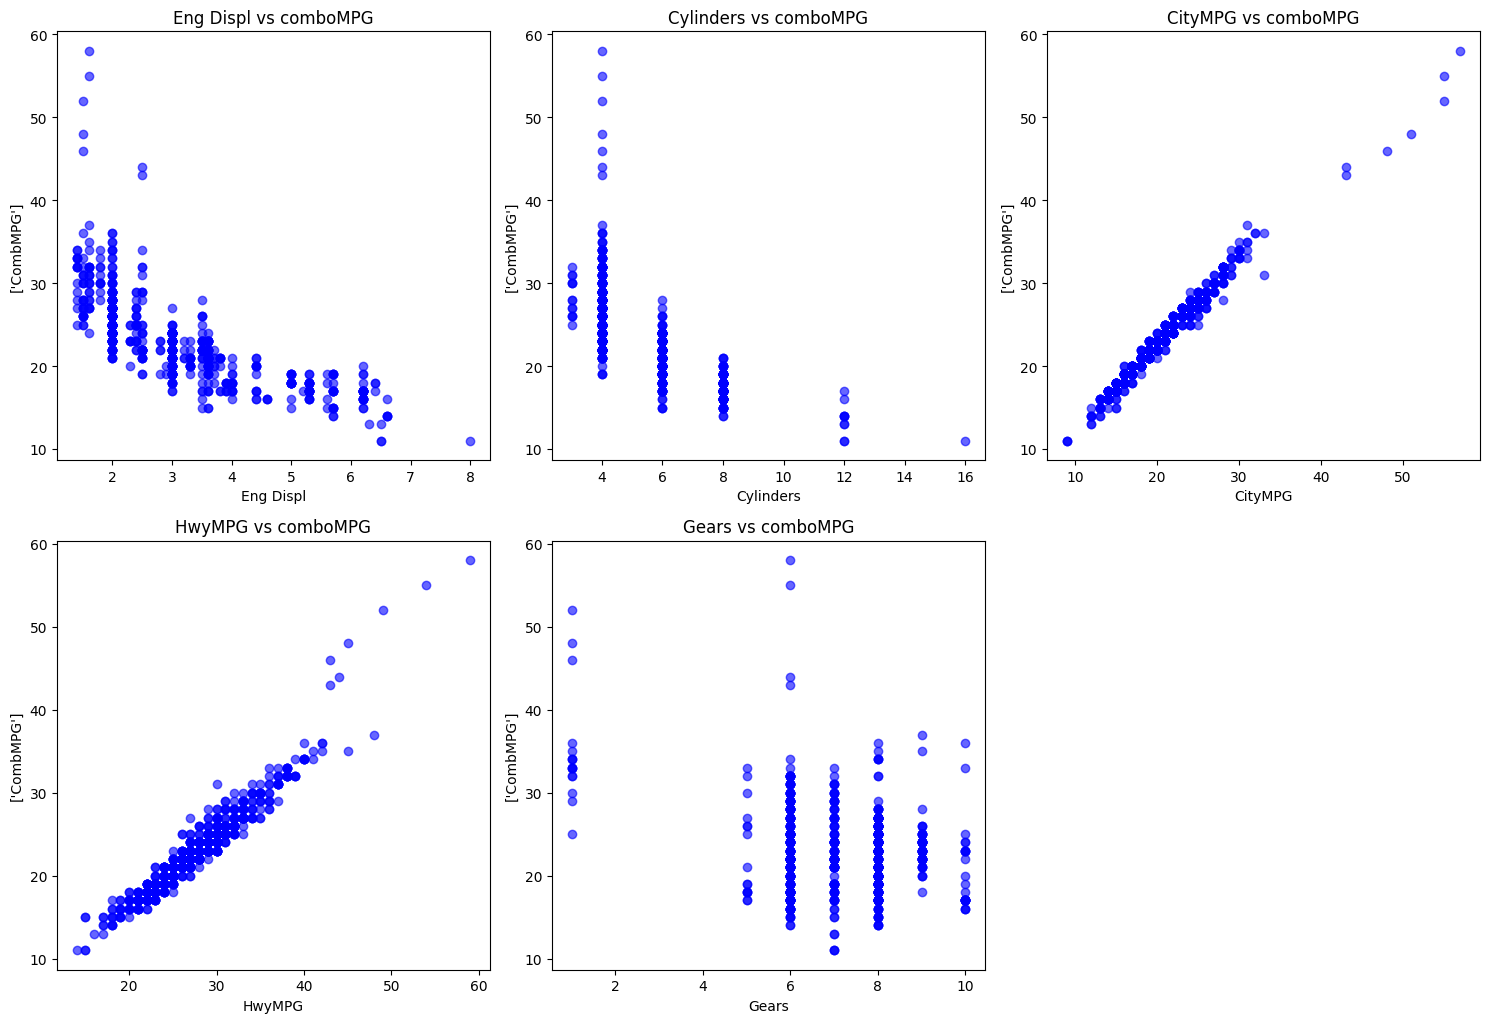

In [32]:
features = ['Eng Displ', 'Cylinders', 'CityMPG', 'HwyMPG','Gears']
target = ['CombMPG']

plt.figure(figsize=(15,15))

for i, col in enumerate(features,1):
  plt.subplot(3,3,i) # 3 rows and 2 columns
  plt.scatter(df[col],df[target],alpha = 0.6, color = 'blue')
  plt.xlabel(col)
  plt.ylabel(target)
  plt.title(f'{col} vs comboMPG')

plt.tight_layout()
plt.show()

In [37]:
df_corr = df.drop(['Mfr Name', 'Carline', 'Transmission'],axis = 1)

In [38]:
corr_matrix = df_corr.corr()
corr_matrix['CombMPG'].sort_values(ascending=False)

,CombMPG
CombMPG,1.000000
CityMPG,0.986509
HwyMPG,0.965120
Gears,-0.303011
Cylinders,-0.717643
Eng Displ,-0.742385


In [46]:
x = df_corr.drop('CombMPG',axis = 1)
y = df_corr['CombMPG']

# **Adding pipeline with standard scaling**

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [47]:
my_pipeline = Pipeline([
    ('std_scaler',StandardScaler())
])
df_tr = my_pipeline.fit_transform(x)

In [48]:
print(df_tr)

[[ 0.67573319  1.43170774 -0.46137553 -0.49258337  0.56565111]
 [ 3.65273233  6.00044621 -2.16115241 -2.45546098 -0.09797225]
 [ 2.31308272  1.43170774 -1.59456012 -1.38480046  0.56565111]
 ...
 [ 1.94095783  1.43170774 -1.40569602 -1.92013072 -0.76159562]
 [-0.81276637 -0.8526615  -0.27251143 -0.31413995  0.56565111]
 [-0.81276637 -0.8526615  -0.08364733 -0.13569653  0.56565111]]


In [49]:
x = df_tr

# **Spliting the dataset into train and test**

In [50]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [51]:
x_train.shape, x_test.shape

((574, 5), (144, 5))

In [52]:
y_train.shape, y_test.shape

((574,), (144,))

# **Training the model**

In [53]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [54]:
model.fit(x_train,y_train)

LinearRegression()

In [55]:
model.intercept_

np.float64(23.13868367223953)

In [56]:
model.coef_

array([-8.20466329e-02, -2.85033364e-03,  3.40859112e+00,  1.98798869e+00,
        4.49033262e-03])

In [57]:
y_pred = model.predict(x_test)
y_pred


array([24.29912823, 31.70473855, 16.53309035, 20.23938577, 24.30368029,
       20.56985053, 24.23042183, 15.85413494, 23.29764435, 17.11690228,
       17.07574759, 20.83131582, 19.24088178, 23.29764435, 20.93055381,
       30.29797719, 46.36631807, 24.00870352, 14.72399611, 21.21033805,
       13.67936311, 31.72618393, 17.09421308, 19.88464227, 24.65387173,
       19.97349759, 27.0012356 , 20.94589288, 22.94290085, 19.13848207,
       32.34283234, 24.29912823, 15.37201503, 17.43049109, 22.23341385,
       24.61597264, 24.23042183, 20.20885417, 33.0110181 , 20.55749135,
       15.76365479, 24.65246401, 23.29921653, 17.15512973, 30.31018983,
       21.26571718, 28.32395149, 21.91684516, 28.66494546, 22.26422116,
       25.71669451, 27.6420162 , 21.56508155, 26.360455  , 14.72399611,
       21.938144  , 24.93990883, 31.37144043, 17.44895658, 20.91097368,
       16.82793794, 20.86012869, 26.7151985 , 20.55749135, 23.30062424,
       24.3007004 , 18.59712129, 20.19366165, 23.98725814, 20.23

# **Checking the model using mathematical functions**

In [61]:
from sklearn.metrics import root_mean_squared_error,mean_squared_error, mean_absolute_error

In [62]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

In [63]:
print('Mean absoluter error = ',mae)
print('Mean Squared error = ',mse)
print('Root Mean Squared error = ',rmse)

Mean absoluter error =  0.2693231617267082
Mean Squared error =  0.1053312571441909
Root Mean Squared error =  0.32454777328490625


## **Visualizing the Accuracy**

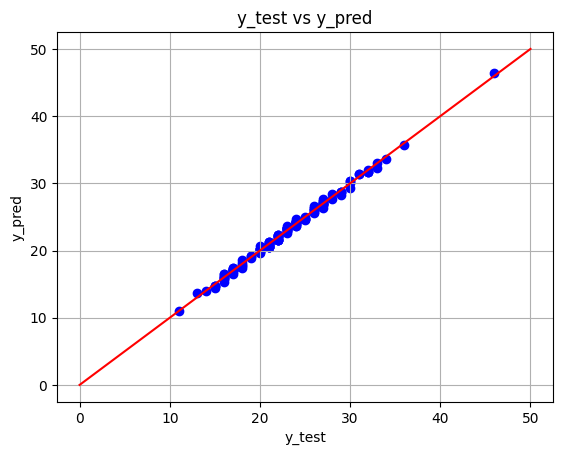

In [68]:
plt.scatter(y_test,y_pred, color = 'blue')
plt.plot([0,50],[0,50],color = "red")
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('y_test vs y_pred')
plt.grid(True)
plt.show()